In [11]:
from diffusers.models import AutoencoderKL
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

In [35]:
SD_VAE_SCALING_FACTOR = 0.18215  

In [69]:
image = plt.imread("sample_image.jpg")
transform = transforms.Compose([transforms.ToTensor(), transforms.Resize((256,256))])
tensor_image = transform(image)
tensor_image = tensor_image.unsqueeze(0)
tensor_image.shape

torch.Size([1, 3, 256, 256])

In [70]:
class VAE(torch.nn.Module):
    def __init__(self, device, freeze: bool, scaling_factor = None, path = "stabilityai/sd-vae-ft-mse"):
        super().__init__()

        self.vae = AutoencoderKL.from_pretrained(path)
        self.vae = self.vae.to(device)

        self.scaling_factor = SD_VAE_SCALING_FACTOR if not scaling_factor else scaling_factor

        if freeze:
            self.vae.eval()
            for p in self.vae.parameters():
                p.requires_grad = False

    def encode(self, normal_grid):
        posterior = self.vae.encode(normal_grid).latent_dist
        mu     = posterior.mean   * self.scaling_factor
        logvar = posterior.logvar + 2 * torch.log(torch.tensor(self.scaling_factor, device=normal_grid.device))
        return mu, logvar

    def decode(self, compressed_grid):
        z = compressed_grid / self.scaling_factor
        reconstructed_grid = self.vae.decode(z)
        return reconstructed_grid

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, grid):
        mu, logvar = self.encode(normal_grid = grid)        # each [B, 4, H/8, W/8]
        z = self.reparameterize(mu = mu, logvar = logvar)   # sampling from gausian distribution
        recon_grid = self.decode(compressed_grid = z)
        return recon_grid.sample

In [71]:
vae = VAE(device = "cpu", freeze = True, scaling_factor = None)

In [72]:
post_vae = vae(tensor_image)
post_vae.shape

torch.Size([1, 3, 256, 256])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10051976..1.0296031].


Text(0.5, 1.0, 'Post vae')

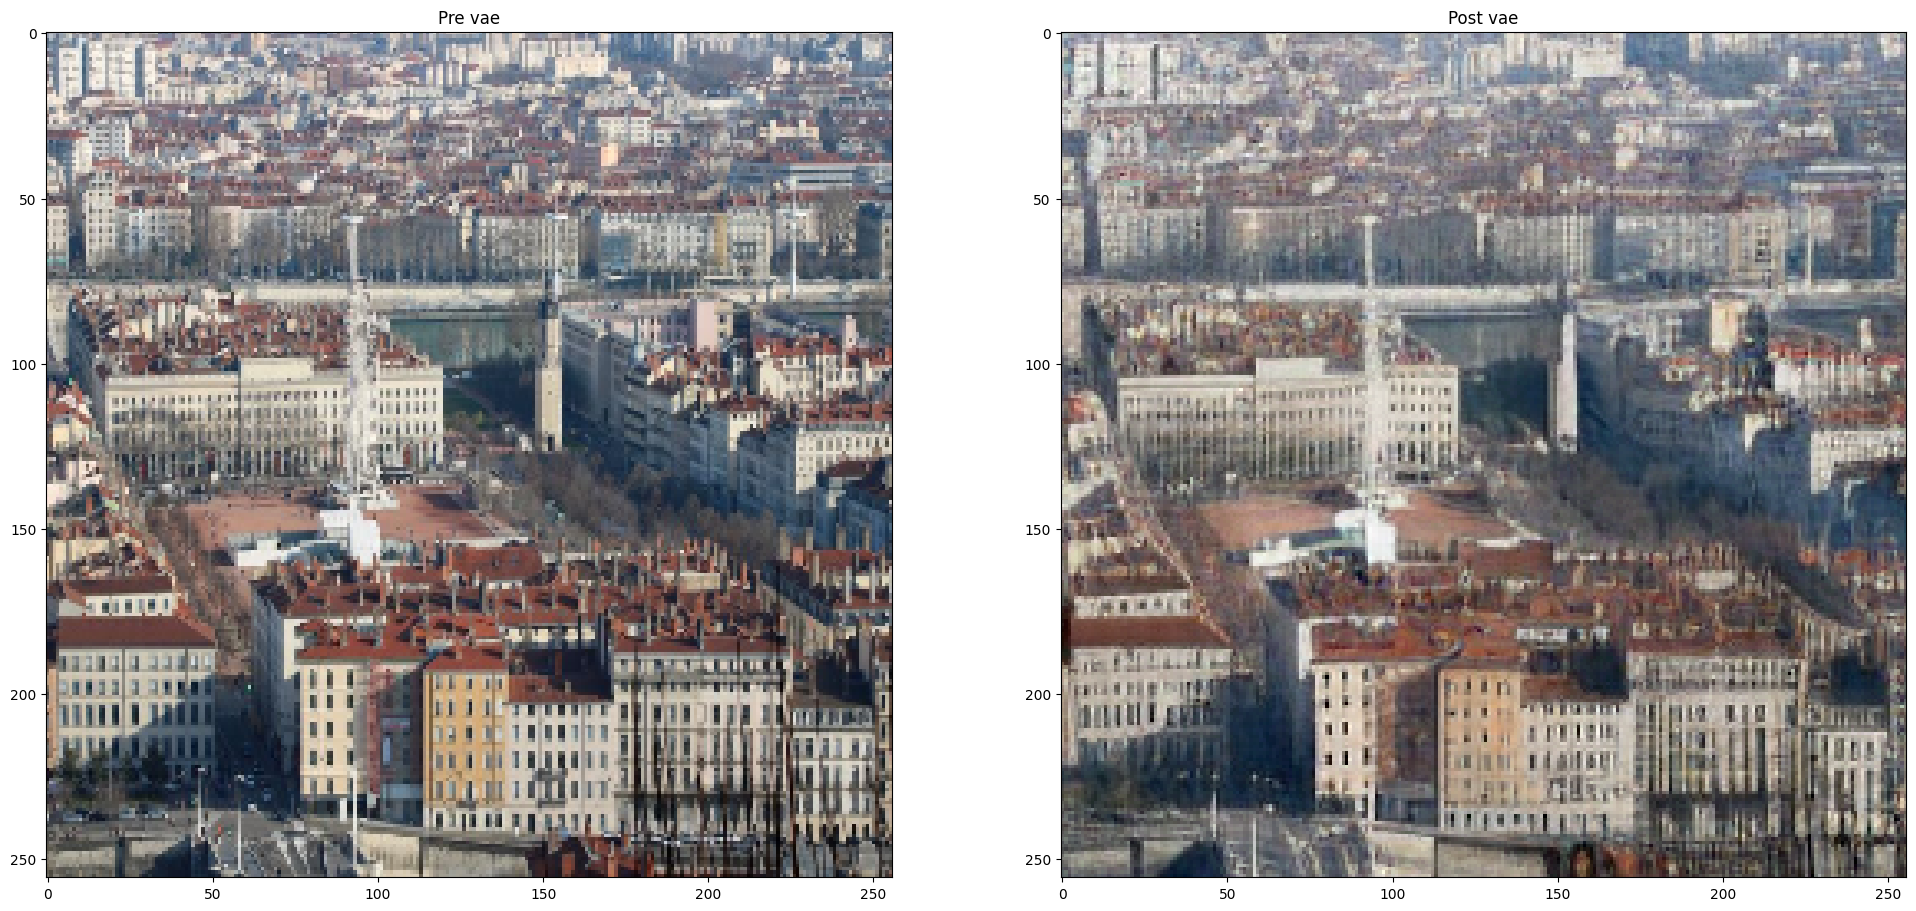

In [73]:
fig, axs = plt.subplots(1, 2, figsize=(24, 24))

axs[0].imshow(tensor_image[0].permute(1,2,0).detach().cpu().numpy())
axs[0].set_title("Pre vae")

axs[1].imshow(post_vae[0].permute(1,2,0).detach().cpu().numpy())
axs[1].set_title("Post vae")
